In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
pd.set_option("display.max_columns", 100)

## step1. 데이터 불러오기 + 병합하기
데이터 병합 어떻게 했냐
- Animal ID를 기준
- 중복 가능성 (한 동물이 여러번 입/퇴소)
- 각 테이블에 DateTime 기준 순번을 매겨서, 같은 순번끼리 매칭되도록 처리

In [4]:
DATA_DIR = r"C:\Users\SAMSUNG\OneDrive\바탕 화면\전건우\매트릭스\반려동물 데이터셋 (2)\반려동물 데이터셋"
print("데이터 폴더 내 파일 목록:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "데이터 폴더 없음 - 먼저 다운로드 필요")

INTAKES_PATH = os.path.join(DATA_DIR, "Austin_Animal_Center_Intakes.csv")
OUTCOMES_PATH = os.path.join(DATA_DIR, "Austin_Animal_Center_Outcomes.csv")
 
intakes = pd.read_csv(INTAKES_PATH)
outcomes = pd.read_csv(OUTCOMES_PATH)
 
print("Intakes shape:", intakes.shape)
print("Outcomes shape:", outcomes.shape)

데이터 폴더 내 파일 목록: ['Austin_Animal_Center_Intakes.csv', 'Austin_Animal_Center_Outcomes.csv', 'Austin_Animal_Center_Stray_Map.csv']
Intakes shape: (124120, 12)
Outcomes shape: (124491, 12)


In [5]:
intakes["DateTime"] = pd.to_datetime(intakes["DateTime"], format ="mixed")
outcomes["DateTime"] = pd.to_datetime(outcomes["DateTime"], format="mixed")
 
intakes = intakes.sort_values(["Animal ID", "DateTime"])
outcomes = outcomes.sort_values(["Animal ID", "DateTime"])
 
intakes["visit_seq"] = intakes.groupby("Animal ID").cumcount()
outcomes["visit_seq"] = outcomes.groupby("Animal ID").cumcount()
 
df = pd.merge(
    intakes,
    outcomes,
    on=["Animal ID", "visit_seq"],
    suffixes=("_intake", "_outcome"),
    how="inner",  # 입소-퇴소 기록이 모두 있는 케이스만 사용 (아직 보호소에 있는 동물은 target이 없으므로 제외)
)
 
print("병합 후 shape:", df.shape)
df.head()

병합 후 shape: (123566, 24)


,Animal ID,Name_intake,DateTime_intake,MonthYear_intake,Found Location,Intake Type,Intake Condition,Animal Type_intake,Sex upon Intake,Age upon Intake,Breed_intake,Color_intake,visit_seq,Name_outcome,DateTime_outcome,MonthYear_outcome,Date of Birth,Outcome Type,Outcome Subtype,Animal Type_outcome,Sex upon Outcome,Age upon Outcome,Breed_outcome,Color_outcome
0,A006100,Scamp,2014-03-07 14:26:00,03/07/2014 02:26:00 PM,8700 Research in Austin (TX),Public Assist,Normal,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White,0,Scamp,2014-03-08 17:10:00,03/08/2014 05:10:00 PM,07/09/2007,Return to Owner,NaN,Dog,Neutered Male,6 years,Spinone Italiano Mix,Yellow/White
1,A006100,Scamp,2014-12-19 10:21:00,12/19/2014 10:21:00 AM,8700 Research Blvd in Austin (TX),Public Assist,Normal,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White,1,Scamp,2014-12-20 16:35:00,12/20/2014 04:35:00 PM,07/09/2007,Return to Owner,NaN,Dog,Neutered Male,7 years,Spinone Italiano Mix,Yellow/White
2,A006100,Scamp,2017-12-07 14:07:00,12/07/2017 02:07:00 PM,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White,2,Scamp,2017-12-07 00:00:00,12/07/2017 12:00:00 AM,07/09/2007,Return to Owner,NaN,Dog,Neutered Male,10 years,Spinone Italiano Mix,Yellow/White
3,A047759,Oreo,2014-04-02 15:55:00,04/02/2014 03:55:00 PM,Austin (TX),Owner Surrender,Normal,Dog,Neutered Male,10 years,Dachshund,Tricolor,0,Oreo,2014-04-07 15:12:00,04/07/2014 03:12:00 PM,04/02/2004,Transfer,Partner,Dog,Neutered Male,10 years,Dachshund,Tricolor
4,A134067,Bandit,2013-11-16 09:02:00,11/16/2013 09:02:00 AM,12034 Research Blvd in Austin (TX),Public Assist,Injured,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White,0,Bandit,2013-11-16 11:54:00,11/16/2013 11:54:00 AM,10/16/1997,Return to Owner,NaN,Dog,Neutered Male,16 years,Shetland Sheepdog,Brown/White


## step2. 기본 탐색
데이터 구조 파악

In [6]:
print("\n[컬럼 목록]")
print(df.columns.tolist())


[컬럼 목록]
['Animal ID', 'Name_intake', 'DateTime_intake', 'MonthYear_intake', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type_intake', 'Sex upon Intake', 'Age upon Intake', 'Breed_intake', 'Color_intake', 'visit_seq', 'Name_outcome', 'DateTime_outcome', 'MonthYear_outcome', 'Date of Birth', 'Outcome Type', 'Outcome Subtype', 'Animal Type_outcome', 'Sex upon Outcome', 'Age upon Outcome', 'Breed_outcome', 'Color_outcome']


In [7]:
print("\n[데이터 타입]")
print(df.dtypes)


[데이터 타입]
Animal ID                      object
Name_intake                    object
DateTime_intake        datetime64[ns]
MonthYear_intake               object
Found Location                 object
Intake Type                    object
Intake Condition               object
Animal Type_intake             object
Sex upon Intake                object
Age upon Intake                object
Breed_intake                   object
Color_intake                   object
visit_seq                       int64
Name_outcome                   object
DateTime_outcome       datetime64[ns]
MonthYear_outcome              object
Date of Birth                  object
Outcome Type                   object
Outcome Subtype                object
Animal Type_outcome            object
Sex upon Outcome               object
Age upon Outcome               object
Breed_outcome                  object
Color_outcome                  object
dtype: object


In [8]:
print("\n[결측치 개수 및 비율]")
missing = df.isnull().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"결측치 수": missing, "결측 비율(%)": missing_ratio})
print(missing_table[missing_table["결측치 수"] > 0])


[결측치 개수 및 비율]
                  결측치 수  결측 비율(%)
Outcome Subtype   66751     54.02
Name_outcome      38956     31.53
Name_intake       38956     31.53
Outcome Type         20      0.02
Age upon Outcome      5      0.00
Sex upon Outcome      1      0.00
Sex upon Intake       1      0.00


## step3. target 변수 정의
- 이진분류하기로 했고, 나중에 구체화하자
- adoption 이 target이고 0또는1


[Outcome Type 분포]
Outcome Type
Adoption           54747
Transfer           36495
Return to Owner    21460
Euthanasia          8341
Died                1148
Rto-Adopt            698
Disposal             568
Missing               68
Relocate              21
NaN                   20
Name: count, dtype: int64

[Target 클래스 비율 - 클래스 불균형 확인]
target_adoption
0    0.557
1    0.443
Name: proportion, dtype: float64


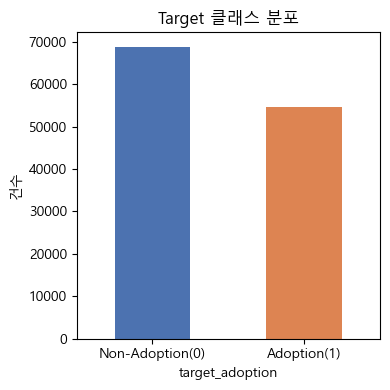

In [9]:
# Outcome Type: Adoption / Transfer / Return to Owner / Euthanasia / Died / Disposal 등
print("\n[Outcome Type 분포]")
print(df["Outcome Type"].value_counts(dropna=False))
 
# Adoption = 1, 나머지 = 0
df = df[df["Outcome Type"].notna()]  # target을 만들기 전에 먼저 제거
df["target_adoption"] = (df["Outcome Type"] == "Adoption").astype(int)
 
print("\n[Target 클래스 비율 - 클래스 불균형 확인]")
print(df["target_adoption"].value_counts(normalize=True).round(3))
 
# 시각화: 클래스 불균형 확인
plt.figure(figsize=(4, 4))
df["target_adoption"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Non-Adoption(0)", "Adoption(1)"], rotation=0)
plt.title("Target 클래스 분포")
plt.ylabel("건수")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=120)
plt.show()
# -> 불균형이 심하면(예: 소수 클래스 20% 미만) 이후 모델링 단계에서
#    class_weight='balanced' 또는 SMOTE 오버샘플링 적용을 검토한다.

## step4. 결측치 처리
- 이름 없는 동물들은 "Unknown"으로 대체하기
- Outcome Subtype: 결측 비율이 높고, target 정보 유출(data leakage) 위험이 있으므로
-> 이 프로젝트에서는 아예 사용하지 않고 컬럼에서 제거한다.
- 단, Sex upon Intake/Outcome: 결측이 소수라면 최빈값으로 대체

In [10]:
df["Name_intake"] = df.get("Name_intake", df.get("Name")).fillna("Unknown")
 
drop_cols = ["Outcome Subtype"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])
 
for col in ["Sex upon Intake", "Sex upon Outcome"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

## stpe5. 이상치 처리 및 나이 전처리
- 나이에서의 이상치는 중앙값으로 대체함

In [11]:
def age_to_days(age_str):
    # '2 years', '3 months', '1 week', '5 days' 형태의 문자열을 일(day) 단위 숫자로 변환
    if pd.isna(age_str):
        return np.nan
    parts = str(age_str).split()
    if len(parts) != 2:
        return np.nan
    num, unit = parts
    try:
        num = int(num)
    except ValueError:
        return np.nan
    unit = unit.lower()
    if "year" in unit:
        return num * 365
    elif "month" in unit:
        return num * 30
    elif "week" in unit:
        return num * 7
    elif "day" in unit:
        return num
    return np.nan

age_col = "Age upon Intake" if "Age upon Intake" in df.columns else "Age upon Outcome"
df["age_days"] = df[age_col].apply(age_to_days)
 
# 이상치 처리: 나이가 음수이거나 비정상적으로 큰 값(예: 30년=10950일 초과) 확인
print("\n[나이(일) 기초 통계]")
print(df["age_days"].describe())
 
upper_bound = 30 * 365  # 30살 초과는 이상치로 간주 (도메인 지식 기반 임계값)
outlier_mask = (df["age_days"] < 0) | (df["age_days"] > upper_bound)
outlier_count = outlier_mask.sum()
print(f"나이 이상치 개수: {outlier_count}")

# 결측 처리 후 중앙값 대체
df.loc[outlier_mask, "age_days"] = np.nan 
df["age_days"] = df.groupby("Animal Type_intake")["age_days"].transform(
    lambda x: x.fillna(x.median()))
df["age_days"] = df["age_days"].fillna(df["age_days"].median())


[나이(일) 기초 통계]
count    123546.000000
mean        750.043741
std        1048.524877
min       -1095.000000
25%          60.000000
50%         365.000000
75%         730.000000
max        9125.000000
Name: age_days, dtype: float64
나이 이상치 개수: 7


## step6. 수치형 변수 처리
- 계절 반영

In [12]:
df["intake_year"] = df["DateTime_intake"].dt.year
df["intake_month"] = df["DateTime_intake"].dt.month
df["intake_weekday"] = df["DateTime_intake"].dt.day_name()
 
def month_to_season(m):
    if m in [1, 2]:
        return "한겨울"
    elif m in [3, 4]:
        return "봄"
    elif m in [5, 6]:
        return "초여름"
    elif m in [7, 8]:
        return "한여름"
    elif m in [9,10]:
        return "가을"
    else:
        return "초겨울"
 
df["intake_season"] = df["intake_month"].apply(month_to_season)

In [13]:
# 몇번 반복해서 방문했는지
df["is_repeat_visit"] = (df["visit_seq"] > 0).astype(int)
print(df["visit_seq"].value_counts())

visit_seq
0     110479
1      10016
2       2051
3        593
4        201
5         96
6         48
7         19
8          9
9          4
10         4
11         3
12         2
13         2
31         1
30         1
23         1
29         1
28         1
27         1
26         1
25         1
24         1
16         1
22         1
21         1
20         1
19         1
18         1
17         1
15         1
14         1
32         1
Name: count, dtype: int64


In [14]:
# 체류 기간(보호소에 머문 일수)
df["length_of_stay_days"] = (df["DateTime_outcome"] - df["DateTime_intake"]).dt.days
print(df["length_of_stay_days"].describe(percentiles=[0.5,0.75,0.9,0.95,0.99]))
print("365일 초과:", (df["length_of_stay_days"] > 365).sum())
df = df[df["length_of_stay_days"] >= 0]  # 음수는 제거

count    123546.000000
mean         17.594337
std          47.676067
min       -2274.000000
50%           5.000000
75%          15.000000
90%          49.000000
95%          77.000000
99%         190.000000
max        1521.000000
Name: length_of_stay_days, dtype: float64
365일 초과: 304


## step7. 범주형 변수 처리
- breed, color
- 이건 카테고리 수가 개많음
- 일단은 상위 몇개 뺴고 다 other로 그룹화하자

In [15]:
# bird 와 livestock 데이터수가 너무 적어서 other로 합침
df["Animal Type_intake"] = df["Animal Type_intake"].replace({
    "Bird": "Other", "Livestock": "Other"
})
df = df[df["Animal Type_intake"].isin(["Dog", "Cat", "Other"])].copy()

In [16]:
print("\nBreed 고유값 개수:", df["Breed_intake"].nunique())
print("Color 고유값 개수:", df["Color_intake"].nunique())
 
TOP_N = 15
 
def group_rare_categories(series, top_n=TOP_N):
    top_categories = series.value_counts().nlargest(top_n).index
    return series.apply(lambda x: x if x in top_categories else "Other")
 
df["breed_grouped"] = group_rare_categories(df["Breed_intake"])
df["color_grouped"] = group_rare_categories(df["Color_intake"])
 
# 순종/혼종 여부 파생 (Breed 문자열에 'Mix' 포함 여부)
df["is_mixed_breed"] = df["Breed_intake"].str.contains("Mix", case=False, na=False).astype(int)


Breed 고유값 개수: 2619
Color 고유값 개수: 594


In [17]:
# 이름 유무 여부
df["has_name"] = (df["Name_intake"].ne("Unknown")).astype(int)

In [18]:
# 성별과 중성화 여부로 분리
df["sex"] = df["Sex upon Intake"].map({
    "Intact Male": "Male",
    "Neutered Male": "Male",
    "Intact Female": "Female",
    "Spayed Female": "Female",
    "Unknown": "Unknown"
}).fillna("Unknown")

df["sterilized_status"] = df["Sex upon Intake"].map({
    "Intact Male": "Not Sterilized",
    "Intact Female": "Not Sterilized",
    "Neutered Male": "Sterilized",
    "Spayed Female": "Sterilized",
    "Unknown": "Unknown"
}).fillna("Unknown")

## step8. EDA 2단계 - Target과 주요 변수 간 관계 시각화

In [19]:
animal_summary = (
    df.groupby("Animal Type_intake", observed=True)
      .agg(
          sample_count=("target_adoption", "size"),
          adoption_count=("target_adoption", "sum"),
          adoption_rate=("target_adoption", "mean")
      ).reset_index())

animal_summary["adoption_rate"] = (animal_summary["adoption_rate"] * 100).round(2)

animal_summary

,Animal Type_intake,sample_count,adoption_count,adoption_rate
0,Cat,45943,21030,45.77
1,Dog,69766,32878,47.13
2,Other,7145,733,10.26


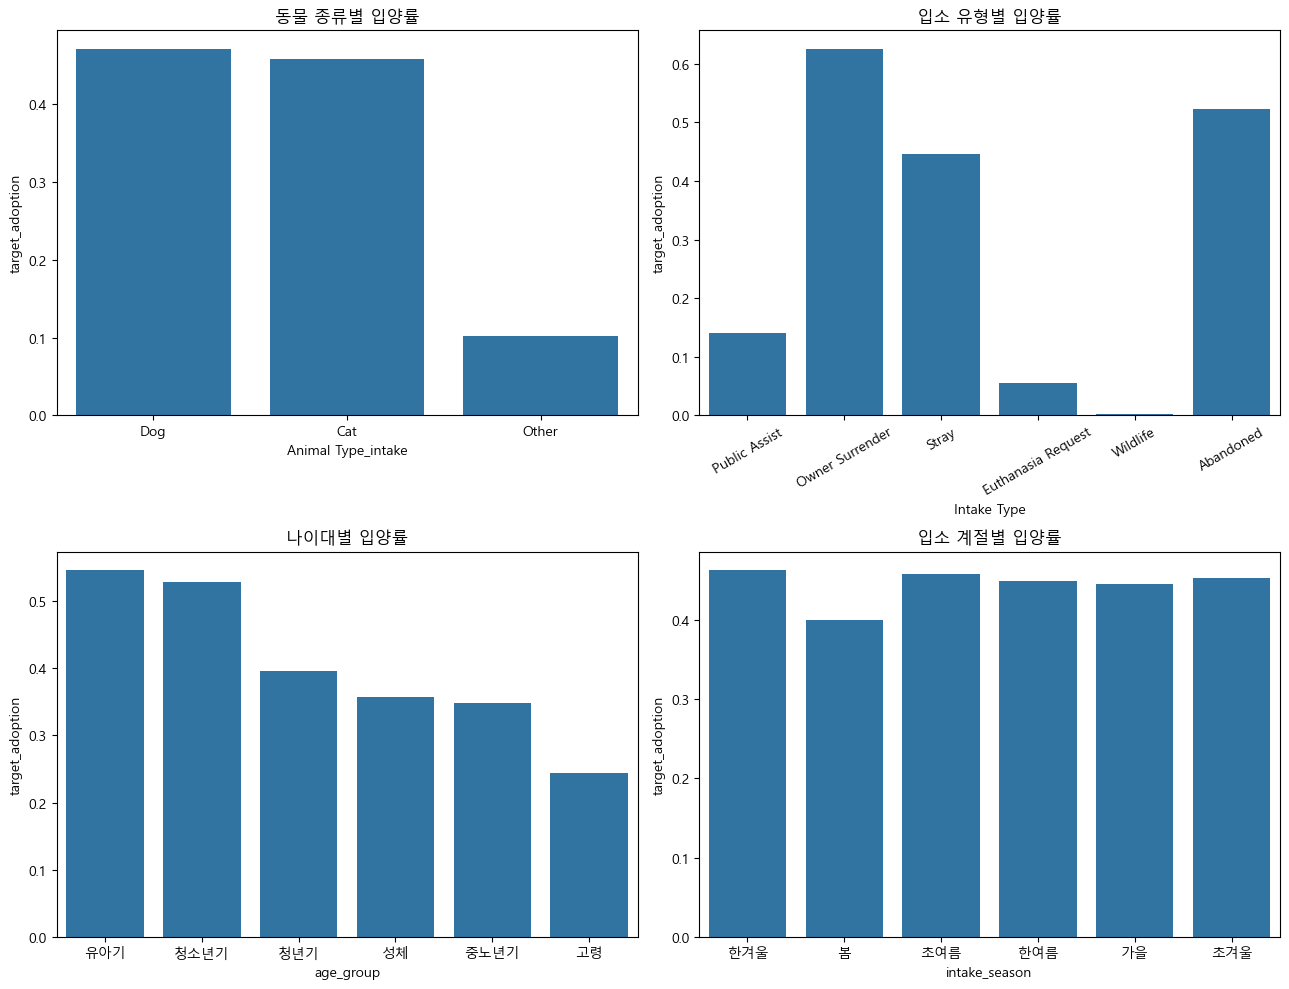

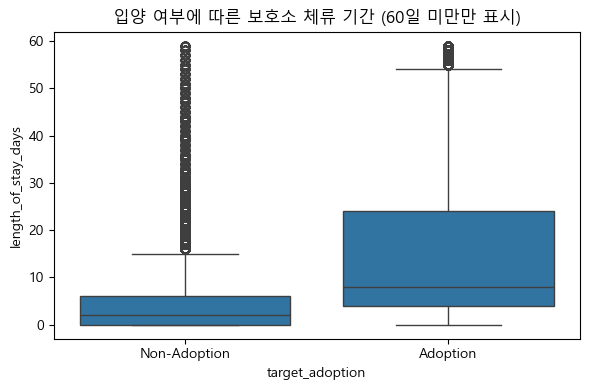

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
 
# (1) 동물 종류별 입양률
sns.barplot(data=df, x="Animal Type_intake", y="target_adoption", order=["Dog","Cat","Other"], ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title("동물 종류별 입양률")
 
# (2) 입소 유형별 입양률
sns.barplot(data=df, x="Intake Type", y="target_adoption", ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title("입소 유형별 입양률")
axes[0, 1].tick_params(axis="x", rotation=30)
 
# (3) 나이(구간화)별 입양률
df["age_group"] = pd.cut(df["age_days"] / 365, bins=[0,0.5,1,3,7,10,30], 
                         labels=["유아기","청소년기","청년기","성체","중노년기","고령"],
                         include_lowest=True,right=False)
sns.barplot(data=df, x="age_group", y="target_adoption", ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("나이대별 입양률")
 
# (4) 계절별 입양률
sns.barplot(data=df, x="intake_season", y="target_adoption", ax=axes[1, 1], errorbar=None,
            order=["한겨울","봄","초여름","한여름","가을","초겨울"])
axes[1, 1].set_title("입소 계절별 입양률")
 
plt.tight_layout()
plt.savefig("eda_target_relationships.png", dpi=120)
plt.show()
 
# 체류 기간과 입양 여부 관계
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[df["length_of_stay_days"] < 60], x="target_adoption", y="length_of_stay_days")
plt.xticks([0, 1], ["Non-Adoption", "Adoption"])
plt.title("입양 여부에 따른 보호소 체류 기간 (60일 미만만 표시)")
plt.tight_layout()
plt.savefig("eda_length_of_stay.png", dpi=120)
plt.show()

## step9. 모델링용 최종 변수 선정 및 인코딩

모델링 단계에서 VIF 점검 결과 발견된 다중공선성 문제 2건 모두 여기에서 해결
- 1. intake month와 intake season이 같은 정보를 중복으로 표현
    - intake season만 사용
- 2. 성별과 중성화 여부가 둘다 같은 값에서 파생되어, 인코딩 후 동일한 컬럼이 되어버림
    - sex_status_unknown으로 합침

In [21]:
feature_cols = [
    "Animal Type_intake", "sex", "sterilized_status", "Intake Type", "Intake Condition",
    "breed_grouped", "color_grouped", "is_mixed_breed", "has_name",
    "age_group", "age_days", "intake_season", "is_repeat_visit"
]
feature_cols = [c for c in feature_cols if c in df.columns]

model_df = df[feature_cols + ["target_adoption"]].copy()
 
# 범주형 변수 One-Hot Encoding
categorical_cols = model_df.select_dtypes(include=["object","category"]).columns.tolist()
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

if {"sex_Unknown", "sterilized_status_Unknown"}.issubset(model_df.columns):
    assert (model_df["sex_Unknown"] == model_df["sterilized_status_Unknown"]).all(), \
        "sex_Unknown과 sterilized_status_Unknown이 더 이상 동일하지 않음 - 위 가정을 다시 확인할 것"
    model_df = model_df.rename(columns={"sex_Unknown": "sex_status_unknown"})
    model_df = model_df.drop(columns=["sterilized_status_Unknown"])
    
print("\n최종 모델링 데이터 shape:", model_df.shape)
print(model_df.head())


최종 모델링 데이터 shape: (122854, 64)
   is_mixed_breed  has_name  age_days  is_repeat_visit  target_adoption  \
0               1         1    2190.0                0                0   
1               1         1    2555.0                1                0   
3               0         1    3650.0                0                0   
4               0         1    5840.0                0                0   
5               0         1    5475.0                0                0   

   Animal Type_intake_Dog  Animal Type_intake_Other  sex_Male  \
0                    True                     False      True   
1                    True                     False      True   
3                    True                     False      True   
4                    True                     False      True   
5                    True                     False     False   

   sex_status_unknown  sterilized_status_Sterilized  \
0               False                          True   
1               

## step10. 데이터셋 분할 + 클래스 불균형 처리 준비

In [22]:
from sklearn.model_selection import GroupShuffleSplit
 
X = model_df.drop(columns=["target_adoption"])
y = model_df["target_adoption"]
groups = df.loc[model_df.index, "Animal ID"]
 
splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42
)

train_idx, test_idx = next(splitter.split(X,y,groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
 
print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train/Test 중복 Animal ID:", len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))
      
# 전처리 완료된 데이터 저장 -> 다음 단계(모델링)에서 바로 불러와서 사용
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Train target 비율:\n", y_train.value_counts(normalize=True).round(3))
print("Test target 비율:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (98253, 63)  Test shape: (24601, 63)
Train/Test 중복 Animal ID: 0
Train target 비율:
 target_adoption
0    0.556
1    0.444
Name: proportion, dtype: float64
Test target 비율:
 target_adoption
0    0.554
1    0.446
Name: proportion, dtype: float64
